# **Global Electric Vehicle (EV) Market Strategy & Consumer Preference Analysis**

---

This dataset captures electric vehicle (EV) market offerings across 2023, tracking geographic distribution, brand portfolio, hardware specifications, promotional procing strategies and target customer segments.

## Introduction

This project explores global ev market distribution, product specs and pricing behaviors. By analyzing how specifications like battery capacity (40-100 kWh) and fast-charging availability map to target buyer segments across regions, the analysis reveals how manufacturers position EV models to drive adoption, balance discounts and meet consumer needs.

# Task One

---

## Data Loading and Initial Exploration

In this section, we load the dataset and examine its structure.

We will check:
- Number of rows and columns
- Column names
- Data types
- Missing values
- Duplicate records
- Basic descriptive statistics

## Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy import stats

In [2]:
car = pd.read_csv(r"C:\Users\MCHARO\Downloads\test (1).csv")
car.head(10)

,Date,Region,Brand,Model,Vehicle_Type,Battery_Capacity_kWh,Discount_Percentage,Customer_Segment,Fast_Charging_Option
0,2023-04,Oceania,Volkswagen,Model 3,SUV,45,16,Budget Conscious,No
1,2023-10,Oceania,Ford,Model 3,Sedan,89,5,Tech Enthusiast,Yes
2,2023-10,South America,Volkswagen,Atto 3,Sedan,61,4,Budget Conscious,Yes
3,2023-02,Africa,Volkswagen,Corolla EV,Crossover,100,16,Eco-Conscious,No
4,2023-10,North America,Tesla,Rio EV,Sedan,70,8,Eco-Conscious,Yes
5,2023-01,Africa,Tesla,Model S,Hatchback,67,6,High Income,No
6,2023-04,North America,Toyota,Atto 3,Truck,41,10,Eco-Conscious,Yes
7,2023-06,Oceania,Ford,ID.3,Sedan,75,19,High Income,No
8,2023-03,Africa,BMW,Han EV,SUV,59,7,Tech Enthusiast,Yes
9,2023-06,North America,BMW,Han EV,Truck,58,6,Budget Conscious,No


# Data Exploration

In [3]:
print("Dataset Shape:", car.shape)
print(f"\nTotal Records: {len(car):,}")
print(f"Memory Usage: {car.memory_usage(deep=True).sum() / 1024 ** 2:.2f} MB")

Dataset Shape: (275, 9)

Total Records: 275
Memory Usage: 0.03 MB


In [4]:
print("Column Names and Types:")
print(car.dtypes)
print("\nFirst 10 Rows:")
car.head(10)

Column Names and Types:
Date                      str
Region                    str
Brand                     str
Model                     str
Vehicle_Type              str
Battery_Capacity_kWh    int64
Discount_Percentage     int64
Customer_Segment          str
Fast_Charging_Option      str
dtype: object

First 10 Rows:


,Date,Region,Brand,Model,Vehicle_Type,Battery_Capacity_kWh,Discount_Percentage,Customer_Segment,Fast_Charging_Option
0,2023-04,Oceania,Volkswagen,Model 3,SUV,45,16,Budget Conscious,No
1,2023-10,Oceania,Ford,Model 3,Sedan,89,5,Tech Enthusiast,Yes
2,2023-10,South America,Volkswagen,Atto 3,Sedan,61,4,Budget Conscious,Yes
3,2023-02,Africa,Volkswagen,Corolla EV,Crossover,100,16,Eco-Conscious,No
4,2023-10,North America,Tesla,Rio EV,Sedan,70,8,Eco-Conscious,Yes
5,2023-01,Africa,Tesla,Model S,Hatchback,67,6,High Income,No
6,2023-04,North America,Toyota,Atto 3,Truck,41,10,Eco-Conscious,Yes
7,2023-06,Oceania,Ford,ID.3,Sedan,75,19,High Income,No
8,2023-03,Africa,BMW,Han EV,SUV,59,7,Tech Enthusiast,Yes
9,2023-06,North America,BMW,Han EV,Truck,58,6,Budget Conscious,No


In [5]:
print("Basic Statistics:")
car.describe()

Basic Statistics:


,Battery_Capacity_kWh,Discount_Percentage
count,275.000000,275.000000
mean,69.440000,8.541818
std,17.122334,5.717903
min,40.000000,0.000000
25%,56.000000,4.000000
50%,69.000000,8.000000
75%,83.500000,14.000000
max,100.000000,20.000000


## Missing Value Analysis

In [6]:
print("Missing Values Analysis:")
missing = car.isnull().sum()
missing_pct = (missing / len(car)) * 100
missing_car = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
}) 

print(missing_car[missing_car['Missing_Count']> 0].sort_values('Missing_Count', ascending = False))
print(f"\nTotal Missing Values: {missing.sum():,}")

Missing Values Analysis:
Empty DataFrame
Columns: [Missing_Count, Percentage]
Index: []

Total Missing Values: 0


## Drop Missing Values

In [7]:
car.dropna(inplace = True)

In [8]:
# Check Missing Values
print("Missing Values after cleaning:", car.isnull().sum())

Missing Values after cleaning: Date                    0
Region                  0
Brand                   0
Model                   0
Vehicle_Type            0
Battery_Capacity_kWh    0
Discount_Percentage     0
Customer_Segment        0
Fast_Charging_Option    0
dtype: int64


## Checking Duplicate Values

In [9]:
# Check number of duplicates
print("Duplicates before cleaning:", car.duplicated().sum())

# Drop duplicated rows
car = car.drop_duplicates()

# Cross checking
print("Duplicates after cleaning:", car.duplicated().sum())

Duplicates before cleaning: 0
Duplicates after cleaning: 0


## Statistical Summary

In [10]:
car.describe()

,Battery_Capacity_kWh,Discount_Percentage
count,275.000000,275.000000
mean,69.440000,8.541818
std,17.122334,5.717903
min,40.000000,0.000000
25%,56.000000,4.000000
50%,69.000000,8.000000
75%,83.500000,14.000000
max,100.000000,20.000000


In [11]:
car.columns

Index(['Date', 'Region', 'Brand', 'Model', 'Vehicle_Type',
       'Battery_Capacity_kWh', 'Discount_Percentage', 'Customer_Segment',
       'Fast_Charging_Option'],
      dtype='str')

# Task Two

---

## Exploratory Data Analysis

## 1. Regions Present

In [12]:
# Load Dataset
car = pd.read_csv(r"C:\Users\MCHARO\Downloads\test (1).csv")
car.head(5)

# Get unique regions as a list
unique_regions = car["Region"].unique().tolist()
print("Unique Regions:", unique_regions)

# Get unique regions with row counts
region_counts = car["Region"].value_counts()
print("\nRegion Distribution:\n", region_counts)

Unique Regions: ['Oceania', 'South America', 'Africa', 'North America', 'Asia', 'Europe']

Region Distribution:
 Region
Oceania          78
Africa           74
North America    71
Asia             32
South America    13
Europe            7
Name: count, dtype: int64


## Bar chart showing Region Distribution

Vehicle Record Count by Region (2023 Dataset) indicated successfully:


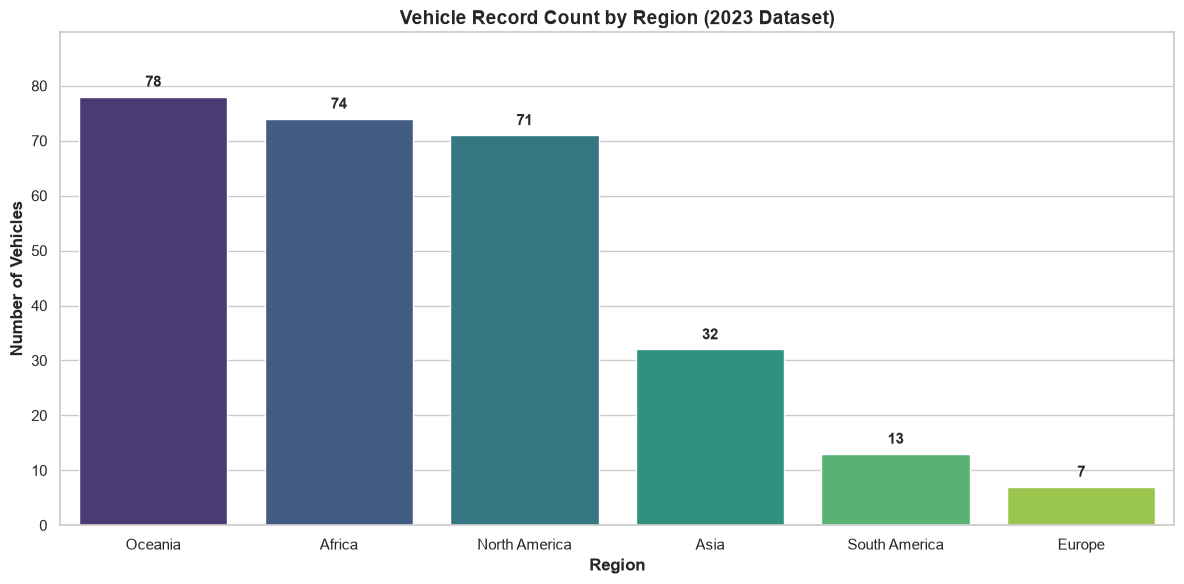

In [13]:
# Load Dataset
car = pd.read_csv(r"C:\Users\MCHARO\Downloads\test (1).csv")

# Calculate region counts
region_counts = car['Region'].value_counts().reset_index()
region_counts.columns = ['Region', 'Count']

# Set style
sns.set_theme(style = "whitegrid")
plt.figure(figsize = (12, 6))

# Create bar plot
ax = sns.barplot(
    data=region_counts,
    x='Region',
    y='Count',
    hue='Region',
    palette='viridis',
    dodge=False,
    legend=False
)

# Add values on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'bottom',
                fontsize = 11, fontweight = 'bold',
                xytext = (0, 5), textcoords = 'offset points')

plt.title('Vehicle Record Count by Region (2023 Dataset)', fontsize = 14, fontweight = 'bold')
plt.xlabel('Region', fontsize = 12, fontweight = 'bold')
plt.ylabel('Number of Vehicles', fontsize = 12, fontweight = 'bold')
plt.ylim(0, max(region_counts['Count']) * 1.15)
plt.tight_layout()

print("Vehicle Record Count by Region (2023 Dataset) indicated successfully:")
plt.show()

## Pie chart showing Region Distribution

Regional Distribution of Vehicles generated successfully:


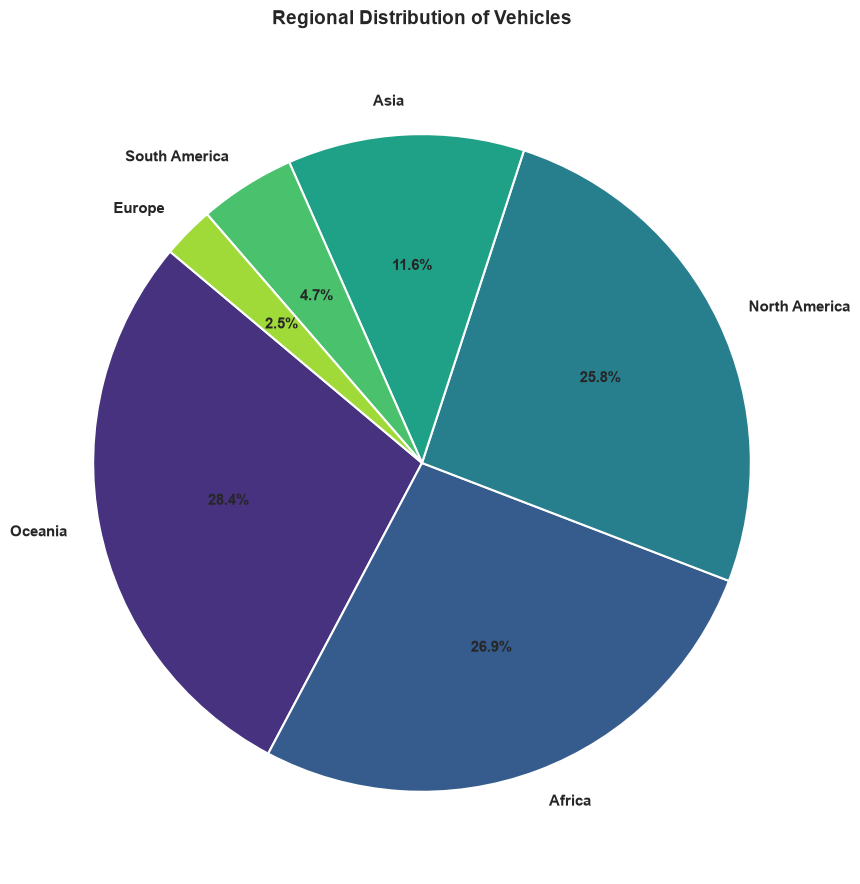

In [14]:
# Load Dataset
car = pd.read_csv(r"C:\Users\MCHARO\Downloads\test (1).csv")

# Calculate region counts
region_counts = car['Region'].value_counts()

# Set color palette
colors = sns.color_palette('viridis', len(region_counts))

plt.figure(figsize = (12, 9))

# Create pie chart
plt.pie(
    region_counts,
    labels = region_counts.index,
    autopct = '%1.1f%%',
    startangle = 140,
    colors = colors,
    wedgeprops = {'edgecolor': 'white', 'linewidth': 1.5},
    textprops = {'fontsize': 11, 'weight':'bold'}
)

plt.title('Regional Distribution of Vehicles', fontsize = 14, fontweight = 'bold', pad = 20)
plt.tight_layout()

print("Regional Distribution of Vehicles generated successfully:")
plt.show()

# 2. Car Brands

In [15]:
# Load Dataset
car = pd.read_csv(r"C:\Users\MCHARO\Downloads\test (1).csv")

# Brand counts
brand_counts = car['Brand'].value_counts()
print("Car Brands present:")
print(brand_counts)

Car Brands present:
Brand
Kia           45
BMW           43
Ford          36
Nissan        35
Hyundai       30
BYD           27
Volkswagen    23
Toyota        22
Tesla         14
Name: count, dtype: int64


## Bar chart showing Car Brands

Vehicle Count by Car Brand generated successfully:


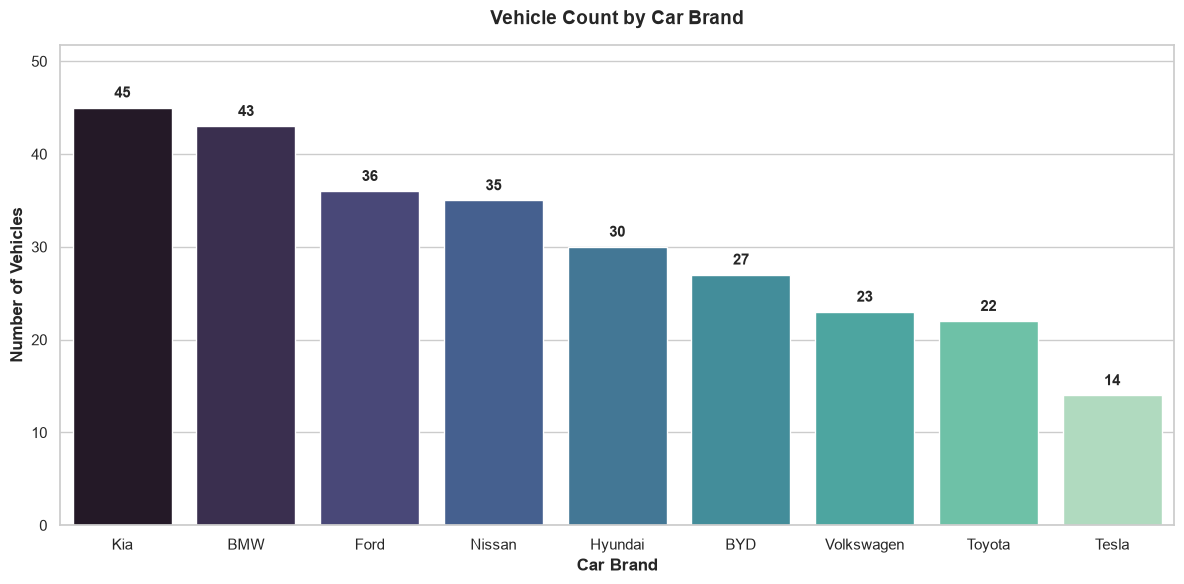

In [16]:
# Load Dataset
car = pd.read_csv(r"C:\Users\MCHARO\Downloads\test (1).csv")

# Brand counts
brand_counts = car['Brand'].value_counts()

# Set style
sns.set_theme(style = "whitegrid")

# 1. Bar Chart
plt.figure(figsize = (12, 6))
ax = sns.barplot(
    x=brand_counts.index,
    y=brand_counts.values,
    hue=brand_counts.index,
    palette='mako',
    dodge=False,
    legend=False
)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
    (p.get_x() + p.get_width() / 2., p.get_height()),
    ha = 'center', va = 'bottom',
    fontsize = 11, fontweight = 'bold',
    xytext = (0, 5), textcoords = 'offset points'
    )

plt.title('Vehicle Count by Car Brand', fontsize = 14, fontweight = 'bold', pad = 15)
plt.xlabel('Car Brand', fontsize = 12, fontweight = 'bold')
plt.ylabel('Number of Vehicles', fontsize = 12, fontweight = 'bold')
plt.ylim(0, max(brand_counts.values) * 1.15)
plt.tight_layout()
print("Vehicle Count by Car Brand generated successfully:")
plt.show()

## Pie Chart showing car brands

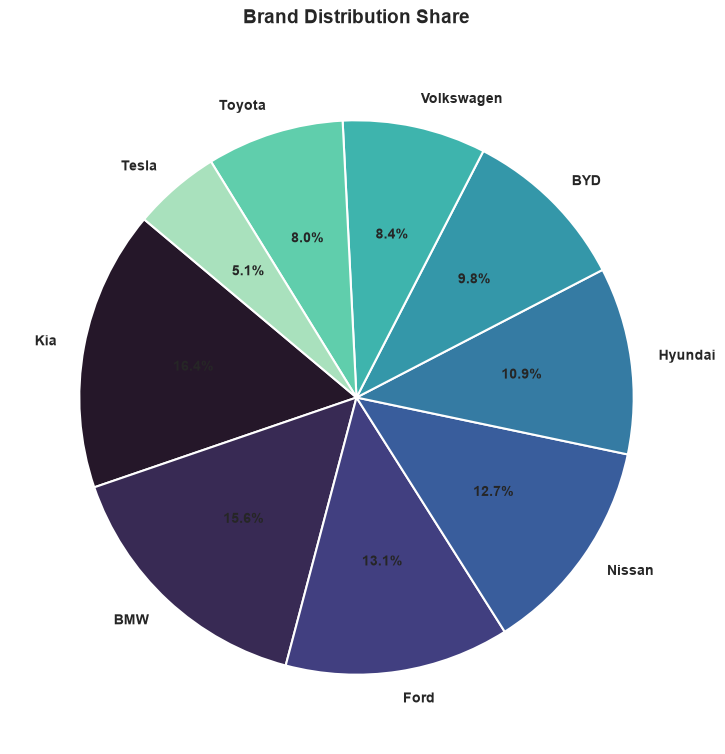

In [17]:
# 2. Pie chart visualization
plt.figure(figsize = (12, 9))
colors = sns.color_palette("mako", len(brand_counts))
plt.pie(
    brand_counts,
    labels = brand_counts.index,
    autopct = "%1.1f%%",
    startangle = 140,
    colors = colors,
    wedgeprops = {"edgecolor": "white", "linewidth": 1.5},
    textprops = {"fontsize": 10, "weight": "bold"},
)
plt.title("Brand Distribution Share", fontsize = 14, fontweight = "bold", pad = 20)
plt.show()

**Brand Distribution Overview**

* **Top Brands:** Kia (16.4%, 45 vehicles) and BMW (15.6%, 43 vehicles) represent nearly a third of all records.

* **Mid-Tier Volume:** Ford (13.1%), Nissan (12.7%), Hyundai (10.9%), and BYD (9.8%) make up the middle segment.

* **Niche Volume:** Volkswagen (8.4%), Toyota (8.0%), and Tesla (5.1%) account for the smallest representations in this sample.

## 3. Car Brands and their models

In [18]:
# Load Dataset
car = pd.read_csv(r"C:\Users\MCHARO\Downloads\test (1).csv")

print("Unique Brands:", car['Brand'].nunique())
print("Unique Models:", car['Model'].nunique())
print("\nBrand vs Model crosstab/counts:")
brand_model = car.groupby(['Brand', 'Model']).size().reset_index(name='Count')
print("Brand vs Models displayed successfully:")
print(brand_model.to_string())

Unique Brands: 9
Unique Models: 17

Brand vs Model crosstab/counts:
Brand vs Models displayed successfully:
          Brand       Model  Count
0           BMW       Ariya      1
1           BMW      Atto 3      1
2           BMW  Corolla EV      3
3           BMW  Elantra EV      3
4           BMW      Han EV      7
5           BMW        ID.3      2
6           BMW        ID.4      2
7           BMW        ID.5      3
8           BMW     Model 3      3
9           BMW     Model Y      2
10          BMW      Rio EV      3
11          BMW   Tucson EV      7
12          BMW          i4      5
13          BMW          iX      1
14          BYD       Ariya      2
15          BYD  Corolla EV      2
16          BYD  Elantra EV      2
17          BYD      Han EV      3
18          BYD        ID.5      2
19          BYD        Leaf      1
20          BYD      Mach-E      2
21          BYD     Model 3      2
22          BYD     Model S      2
23          BYD     Model Y      4
24          BYD  

## 

## Heatmap showing Brands vs Models

Brand vs. Model Distribution Matrix (Heatmap) generated successfully:


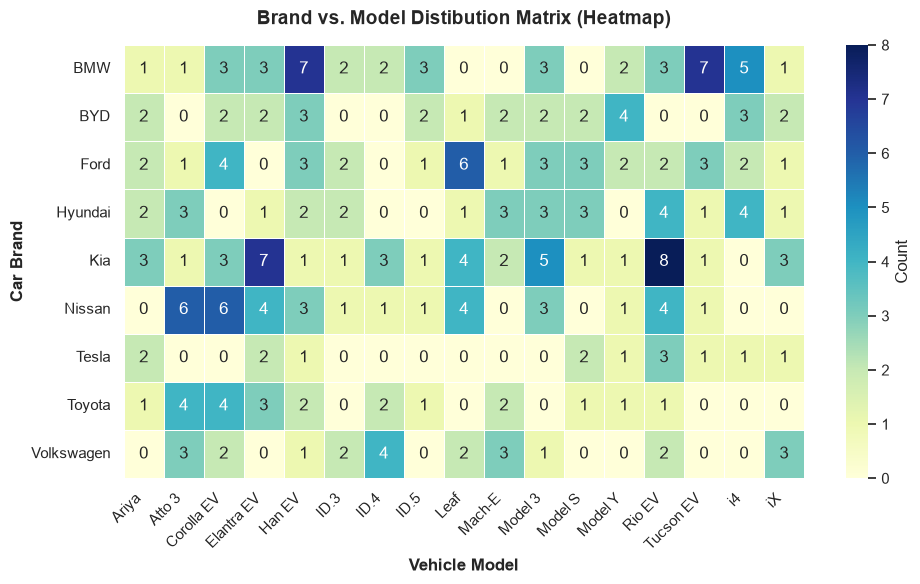

In [19]:
# Load Dataset
car = pd.read_csv(r"C:\Users\MCHARO\Downloads\test (1).csv")

# Prepare crosstab
ct = pd.crosstab(car['Brand'], car['Model'])

# 1. Heatmap
plt.figure(figsize = (10, 6))
sns.heatmap(ct, annot = True, fmt = 'd', cmap = 'YlGnBu', cbar_kws = {'label': 'Count'}, linewidth = 0.5)
plt.title('Brand vs. Model Distibution Matrix (Heatmap)', fontsize = 14, fontweight = 'bold', pad = 15)
plt.xlabel('Vehicle Model', fontsize = 12, fontweight = 'bold')
plt.ylabel('Car Brand', fontsize = 12, fontweight = 'bold')
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
print("Brand vs. Model Distribution Matrix (Heatmap) generated successfully:")
plt.show()

## Horizontal Stacked Bar Chart showing Brands vs Models

Brand vs. Model Distribution Matrix (Heatmap) generated successfully:


<Figure size 1200x700 with 0 Axes>

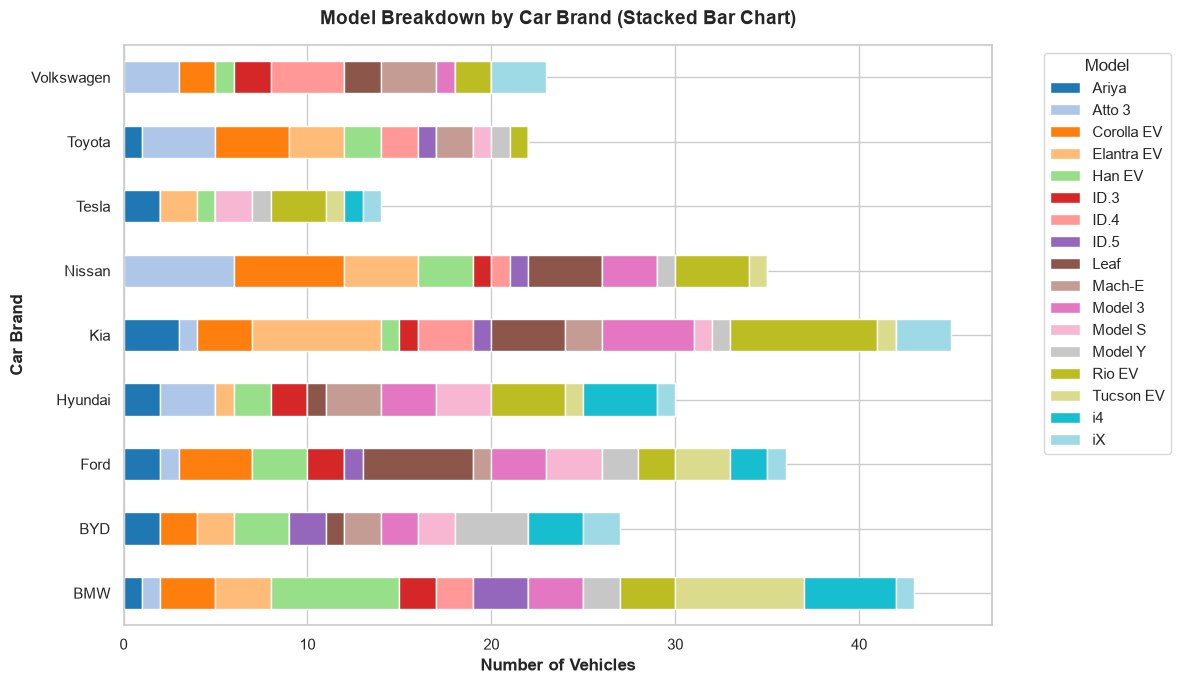

In [20]:
# 2. Horizontal Stacked Bar Chart
plt.figure(figsize = (12, 7))
ct.plot(kind = 'barh', stacked = True, colormap = 'tab20', figsize = (12, 7))
plt.title('Model Breakdown by Car Brand (Stacked Bar Chart)', fontsize = 14, fontweight = 'bold', pad = 15)
plt.xlabel('Number of Vehicles', fontsize = 12, fontweight = 'bold')
plt.ylabel('Car Brand', fontsize = 12, fontweight = 'bold')
plt.legend(title = 'Model', bbox_to_anchor = (1.05, 1), loc = "upper left")
plt.tight_layout()
print("Brand vs. Model Distribution Matrix (Heatmap) generated successfully:")
plt.show()

**Brand Distribution & Portfolio Depth**

* **Brand Leadership:** Kia ($N=45$, $16.4\%$) and BMW ($N=43$, $15.6\%$) lead overall listing volume, while Tesla ($N=14$, $5.1\%$) accounts for the smallest brand representation.

* **Balanced Model Spread:** Each brand spans between 11 and 16 distinct model names, indicating a broad distribution rather than concentration under a single marquee vehicle.

**Cross-Brand Model Assignment (Synthetic Data Pattern)**

* **Cross-OEM Model Sharing:** All 17 distinct model names in the dataset appear under multiple competing brand labels (e.g., Han EV is assigned across 9 different brands, and Rio EV appears under 8 brands).

* **Cross-Category Nomenclature:** Model names typically associated with specific automakers (such as Tesla's Model 3 and Model S, or BYD's Atto 3 and Han EV) are distributed across non-parent manufacturers like Kia, BMW, Ford, and Nissan.

**Top Brand-Model Combinations**

* **Highest Frequency Pairings:** The most frequent brand-model combinations are Kia Rio EV ($N=8$), BMW Tucson EV ($N=7$), BMW Han EV ($N=7$), and Kia Elantra EV ($N=7$).

* **Uniform Granularity:** Out of 127 unique Brand-Model pairs present, 83.5% ($N=106$) contain between 1 and 3 vehicles, reflecting a highly fragmented long-tail distribution.

## 4. Car Brands and their Types

In [21]:
# Load Dataset
car = pd.read_csv(r"C:\Users\MCHARO\Downloads\test (1).csv")

# 1. Cross-tabulation between Car Brands and vehicle types
print("Columns:", car.columns)

# Check exact column name for vehicle type
type_col = [c for c in car.columns if 'type' in c.lower() or 'body' in c.lower() or 'segment' in c.lower()]
print("Type columns:", type_col)

print(car[['Brand'] + type_col].head())

Columns: Index(['Date', 'Region', 'Brand', 'Model', 'Vehicle_Type',
       'Battery_Capacity_kWh', 'Discount_Percentage', 'Customer_Segment',
       'Fast_Charging_Option'],
      dtype='str')
Type columns: ['Vehicle_Type', 'Customer_Segment']
        Brand Vehicle_Type  Customer_Segment
0  Volkswagen          SUV  Budget Conscious
1        Ford        Sedan   Tech Enthusiast
2  Volkswagen        Sedan  Budget Conscious
3  Volkswagen    Crossover     Eco-Conscious
4       Tesla        Sedan     Eco-Conscious


## Key observations for vehicle brand and models in this dataset

In [22]:
# Load Dataset
car = pd.read_csv(r"C:\Users\MCHARO\Downloads\test (1).csv")

# 1. Brand Counts
brand_counts = car['Brand'].value_counts()

# 2. Total unique models
unique_models = car['Model'].nunique()

# 3. Model breakdown per brand
brand_model_pivot = pd.crosstab(car['Brand'], car['Model'])

# 4. Top brand model combinations
top_combos = car.groupby(['Brand', 'Model']).size().reset_index(name='Count').sort_values('Count', ascending=False)

# 5. Check if models are shared across brands
models_per_brand = car.groupby('Model')['Brand'].nunique()

print("Brand Counts:\n", brand_counts)
print("\nUnique Models Count:", unique_models)
print("\nTop 10 Brand-Model Combinations:\n", top_combos.head(10))
print("\nModels shared across multiple brands:\n", models_per_brand[models_per_brand > 1])

Brand Counts:
 Brand
Kia           45
BMW           43
Ford          36
Nissan        35
Hyundai       30
BYD           27
Volkswagen    23
Toyota        22
Tesla         14
Name: count, dtype: int64

Unique Models Count: 17

Top 10 Brand-Model Combinations:
       Brand       Model  Count
67      Kia      Rio EV      8
4       BMW      Han EV      7
57      Kia  Elantra EV      7
11      BMW   Tucson EV      7
70   Nissan      Atto 3      6
71   Nissan  Corolla EV      6
32     Ford        Leaf      6
12      BMW          i4      5
64      Kia     Model 3      5
52  Hyundai          i4      4

Models shared across multiple brands:
 Model
Ariya         7
Atto 3        7
Corolla EV    7
Elantra EV    7
Han EV        9
ID.3          6
ID.4          5
ID.5          6
Leaf          6
Mach-E        6
Model 3       7
Model S       6
Model Y       7
Rio EV        8
Tucson EV     6
i4            5
iX            7
Name: Brand, dtype: int64


**Brand Distribution & Portfolio Depth**

* **Brand Leadership:** Kia ($N=45$, $16.4\%$) and BMW ($N=43$, $15.6\%$) lead overall listing volume, while Tesla ($N=14$, $5.1\%$) accounts for the smallest brand representation.

* **Balanced Model Spread:** Each brand spans between 11 and 16 distinct model names, indicating a broad distribution rather than concentration under a single marquee vehicle.

**Cross-Brand Model Assignment (Synthetic Data Pattern)**

* **Cross-OEM Model Sharing:** All 17 distinct model names in the dataset appear under multiple competing brand labels (e.g., Han EV is assigned across 9 different brands, and Rio EV appears under 8 brands).

* **Cross-Category Nomenclature:** Model names typically associated with specific automakers (such as Tesla's Model 3 and Model S, or BYD's Atto 3 and Han EV) are distributed across non-parent manufacturers like Kia, BMW, Ford, and Nissan.

**Top Brand-Model Combinations** 

* **Highest Frequency Pairings:** The most frequent brand-model combinations are Kia Rio EV ($N=8$), BMW Tucson EV ($N=7$), BMW Han EV ($N=7$), and Kia Elantra EV ($N=7$).

* **Uniform Granularity:** Out of 127 unique Brand-Model pairs present, 83.5% ($N=106$) contain between 1 and 3 vehicles, reflecting a highly fragmented long-tail distribution.

## Visualizations for vehicle brands and vehicle type

In [23]:
# Load Dataset
car = pd.read_csv(r"C:\Users\MCHARO\Downloads\test (1).csv")

# 1. Cross-tabulation between brand and vehicle type or body style
print("Columns", car.columns)

# Check exact column name for vehicle type
type_col = [c for c in car.columns if 'type' in c.lower() or 'body' in c.lower() or 'segment' in c.lower()]
print("Type Columns:", type_col)

print(car[['Brand'] + type_col].head())

Columns Index(['Date', 'Region', 'Brand', 'Model', 'Vehicle_Type',
       'Battery_Capacity_kWh', 'Discount_Percentage', 'Customer_Segment',
       'Fast_Charging_Option'],
      dtype='str')
Type Columns: ['Vehicle_Type', 'Customer_Segment']
        Brand Vehicle_Type  Customer_Segment
0  Volkswagen          SUV  Budget Conscious
1        Ford        Sedan   Tech Enthusiast
2  Volkswagen        Sedan  Budget Conscious
3  Volkswagen    Crossover     Eco-Conscious
4       Tesla        Sedan     Eco-Conscious


## Grouped Bar Chart

Cross-tabulation:
 Vehicle_Type  Coupe  Crossover  Hatchback  SUV  Sedan  Truck
Brand                                                       
BMW               6          5         12    9      2      9
BYD               4          3         11    3      3      3
Ford              4          6         14    5      3      4
Hyundai           2          3         14    4      3      4
Kia               7          5          8    8      6     11
Nissan            4          5          4   11      5      6
Tesla             2          1          7    2      1      1
Toyota            2          0          7    5      4      4
Volkswagen        3          1          8    4      4      3
Vehicle Count by Brand and Vehicle Type generated successfully:


<Figure size 1200x600 with 0 Axes>

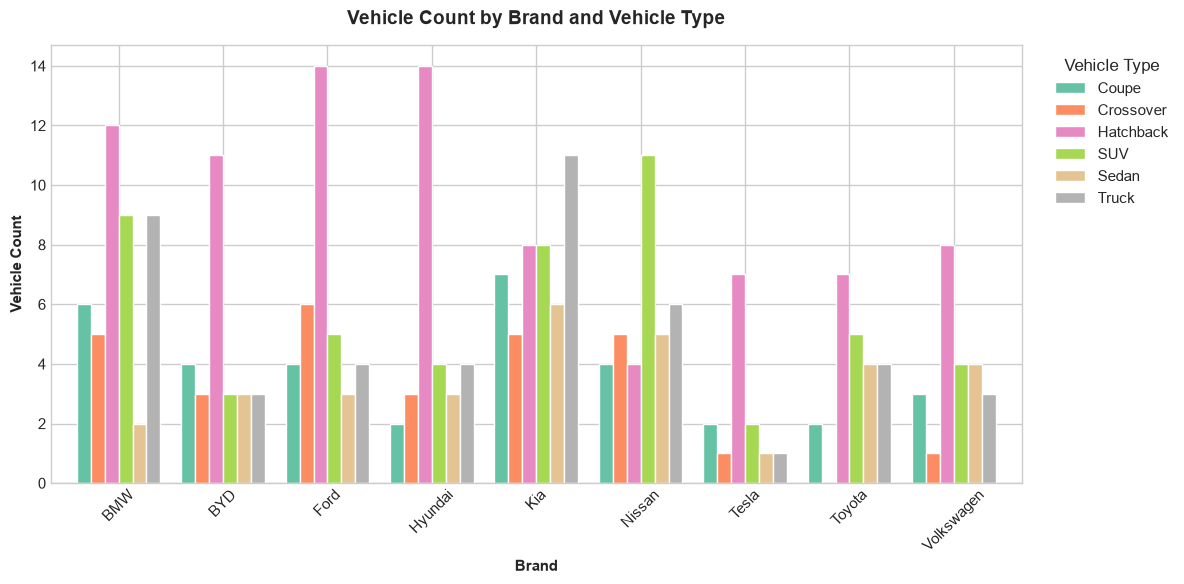

In [24]:
# Load Dataset
car = pd.read_csv(r"C:\Users\MCHARO\Downloads\test (1).csv")

# Create cross-tabulation
ct = pd.crosstab(car['Brand'], car['Vehicle_Type'])
print("Cross-tabulation:\n", ct)

# Visualizations
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Figure 1. Grouped Bar Char
plt.figure(figsize = (12, 6))
ct.plot(kind='bar', stacked=False, colormap='Set2', figsize=(12, 6), width = 0.8)
plt.title('Vehicle Count by Brand and Vehicle Type', fontsize=14, fontweight='bold', pad = 15)
plt.xlabel('Brand', fontsize=11, fontweight='bold')
plt.ylabel('Vehicle Count', fontsize=11, fontweight='bold')
plt.xticks(rotation=45)
plt.legend(title='Vehicle Type', bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
print("Vehicle Count by Brand and Vehicle Type generated successfully:")
plt.show()

Heatmap: Brand vs. Vehicle Type Density generated successfully:


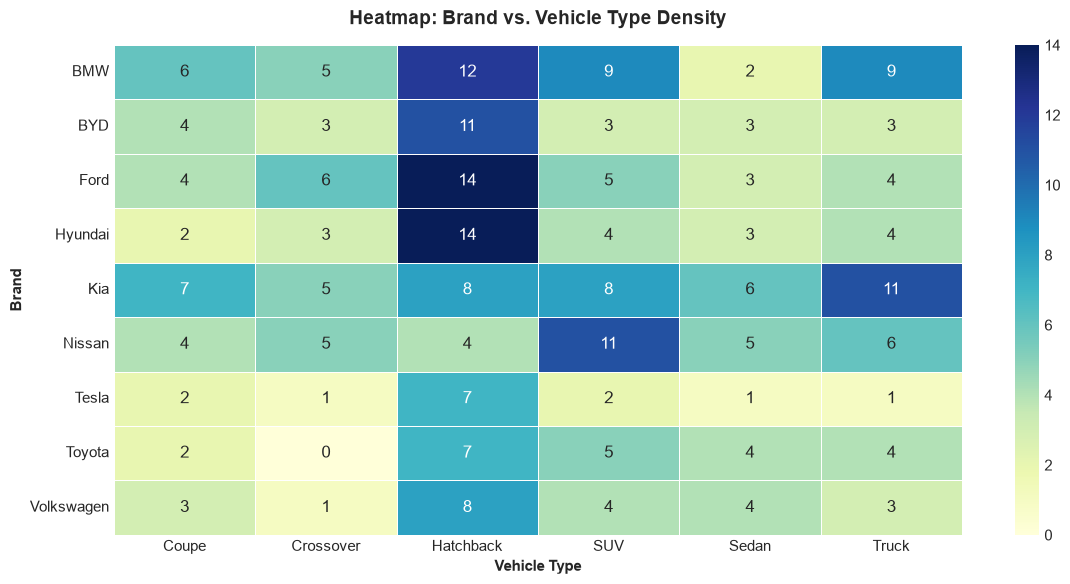

In [25]:
# Figure 2:Heatmap
plt.figure(figsize = (12, 6))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu', cbar=True, linewidth=0.5)
plt.title('Heatmap: Brand vs. Vehicle Type Density', fontsize = 14, fontweight = 'bold', pad=15)
plt.xlabel('Vehicle Type', fontsize = 11, fontweight='bold')
plt.ylabel('Brand', fontsize=11, fontweight='bold')
plt.tight_layout()
print("Heatmap: Brand vs. Vehicle Type Density generated successfully:")
plt.show()

**Key Visualization Takeaways**

* **Hatchback Dominance:** Hatchbacks represent the highest volume across most individual brands, peaking at 14 listings each for Ford and Hyundai, and 12 listings for BMW.

* **Body Style Outliers:** Nissan diverges from the hatchback trend by having its primary concentration in SUVs ($N=11$), while Kia holds the highest single concentration of Trucks ($N=11$).

* **Rare Combinations:** Crossovers are the least represented body style for Toyota ($N=0$) and Volkswagen ($N=1$). Sedans maintain low overall volume across all automakers (ranging between 1 and 6 listings per brand).

## 5. Car Brands and Battery Capacity (kWh)

C:\Users\MCHARO\AppData\Local\Temp\ipykernel_7932\3677341435.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


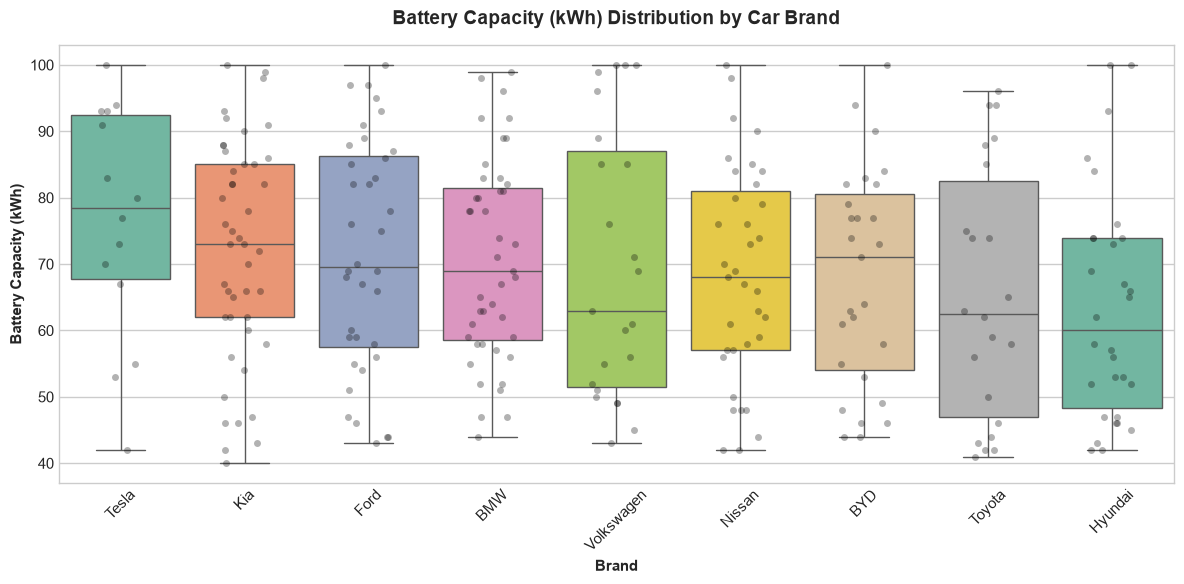

C:\Users\MCHARO\AppData\Local\Temp\ipykernel_7932\3677341435.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


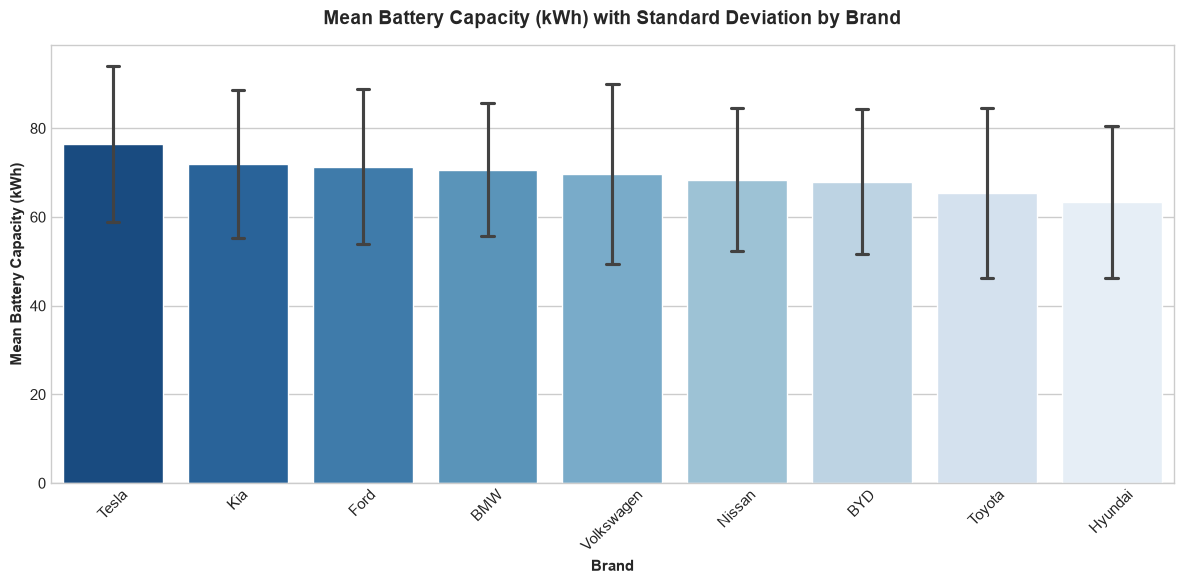

In [26]:
# Load Dataset
car = pd.read_csv(r"C:\Users\MCHARO\Downloads\test (1).csv")

# Compute summary stats
stats = (
    car.groupby("Brand")["Battery_Capacity_kWh"]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
    .sort_values(by="mean", ascending=False)
)

# Figure 1: Boxplot with Strip Plot
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=car,
    x="Brand",
    y="Battery_Capacity_kWh",
    palette="Set2",
    order=stats["Brand"],
)
sns.stripplot(
    data=car,
    x="Brand",
    y="Battery_Capacity_kWh",
    color="black",
    alpha=0.3,
    jitter=0.2,
    order=stats["Brand"],
)
plt.title(
    "Battery Capacity (kWh) Distribution by Car Brand",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Brand", fontsize=11, fontweight="bold")
plt.ylabel("Battery Capacity (kWh)", fontsize=11, fontweight="bold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Figure 2: Mean Battery Capacity with Standard Deviation
plt.figure(figsize=(12, 6))
sns.barplot(
    data=car,
    x="Brand",
    y="Battery_Capacity_kWh",
    palette="Blues_r",
    order=stats["Brand"],
    errorbar="sd",
    capsize=0.1,
)
plt.title(
    "Mean Battery Capacity (kWh) with Standard Deviation by Brand",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Brand", fontsize=11, fontweight="bold")
plt.ylabel("Mean Battery Capacity (kWh)", fontsize=11, fontweight="bold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [27]:
# Calculate summary statistics for battery capacity by brand
brand_battery_stats = (
    car.groupby("Brand")["Battery_Capacity_kWh"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .reset_index()
)
brand_battery_stats = brand_battery_stats.sort_values(by='mean', ascending=False)
print("Battery Capacity Summary Stats by Brand:\n", brand_battery_stats)


Battery Capacity Summary Stats by Brand:
         Brand  count       mean  median        std  min  max
6       Tesla     14  76.500000    78.5  17.579490   42  100
4         Kia     45  72.022222    73.0  16.646715   40  100
2        Ford     36  71.361111    69.5  17.455499   43  100
0         BMW     43  70.674419    69.0  15.055012   44   99
8  Volkswagen     23  69.739130    63.0  20.266895   43  100
5      Nissan     35  68.400000    68.0  16.172235   42  100
1         BYD     27  68.000000    71.0  16.398874   44  100
7      Toyota     22  65.454545    62.5  19.185131   41   96
3     Hyundai     30  63.400000    60.0  17.169741   42  100


**Key Analytical Findings**

* **Highest Mean Capacity:** Tesla achieves the highest average battery capacity (76.5 kWh), followed by Kia (72.0 kWh) and Ford (71.4 kWh).

* **Lowest Mean Capacity:** Hyundai (63.4 kWh) and Toyota (65.5 kWh) display lower overall mean capacities across their listings.

* **Uniform Range Boundaries:** Across almost all individual brands, battery sizes span virtually the full synthetic dataset range—from ~$\mathbf{40\text{ kWh}}$ up to $\mathbf{100\text{ kWh}}$.

* **Highest Variance:** Volkswagen exhibits the widest spread and standard deviation ($\mathbf{20.27\text{ kWh}}$), reflecting a notable gap between its mean ($\mathbf{69.7\text{ kWh}}$) and median ($\mathbf{63.0\text{ kWh}}$).

* **Lowest Variance:** BMW maintains the tightest standard deviation ($\mathbf{15.06\text{ kWh}}$), keeping its listings closely grouped around its $\mathbf{69.0\text{ kWh}}$ median.

## 6. Car Brand Model breakdown by Customer Segment

In [28]:
# Load Dataset
car = pd.read_csv(r"C:\Users\MCHARO\Downloads\test (1).csv")

# 1. Cross-tabulation between Brand and Customer Segment
brand_segment_ct = pd.crosstab(car['Brand'], car['Customer_Segment'])
print("Brand vs. Customer Segment:\n", brand_segment_ct)

# 2. Percentage distribution of customer segment per brand
brand_segment_pct = pd.crosstab(car['Brand'], car['Customer_Segment'], normalize='index')*100
print("Percentage Distribution of Customer Segment by Brand:\n", brand_segment_pct)

Brand vs. Customer Segment:
 Customer_Segment  Budget Conscious  Eco-Conscious  High Income  Middle Income  \
Brand                                                                           
BMW                             16              8           11              3   
BYD                              6              5            9              4   
Ford                            10              7            7              4   
Hyundai                         12              7            3              2   
Kia                             14              8            9              5   
Nissan                           8             11            7              3   
Tesla                            3              3            4              3   
Toyota                          10              2            6              1   
Volkswagen                      13              2            1              1   

Customer_Segment  Tech Enthusiast  
Brand                              
BMW    

Customer Segment Breakdown by Car Brand (%) generated successfully:


<Figure size 1200x600 with 0 Axes>

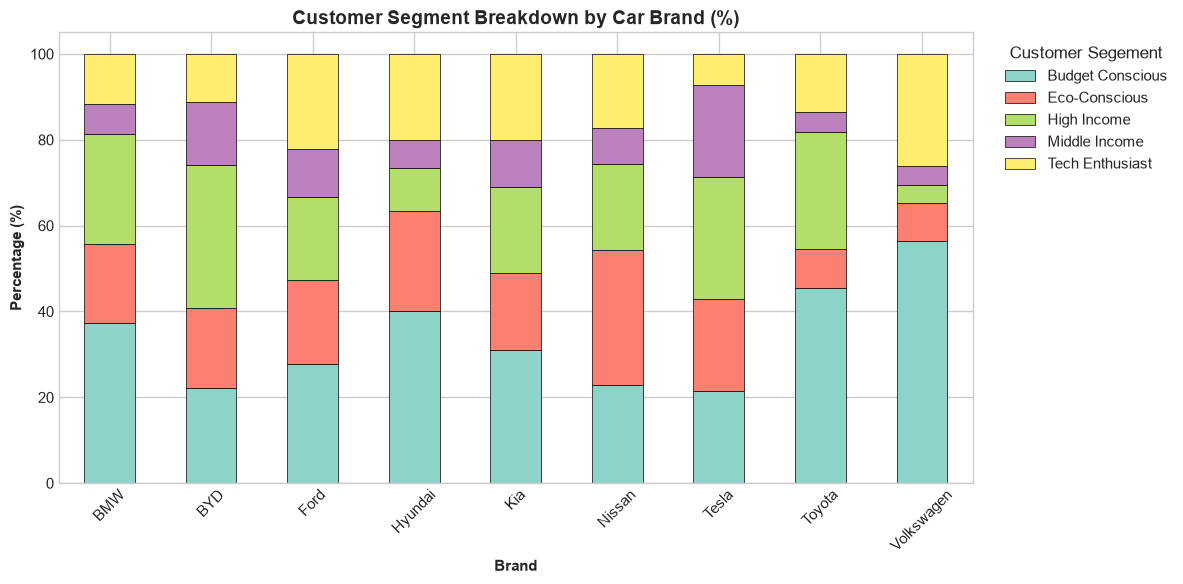

In [29]:
# Plot 1: Stacked Bar Chart for Brand vs Customer Segment
plt.figure(figsize = (12, 6))
brand_segment_pct.plot(kind='bar', stacked=True, colormap='Set3', figsize=(12, 6), edgecolor='black', linewidth=0.5)
plt.title('Customer Segment Breakdown by Car Brand (%)', fontsize = 14, fontweight = 'bold')
plt.xlabel('Brand', fontsize = 11, fontweight = 'bold')
plt.ylabel('Percentage (%)', fontsize = 11, fontweight = 'bold')
plt.legend(title = 'Customer Segement', bbox_to_anchor = (1.02, 1), loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
print("Customer Segment Breakdown by Car Brand (%) generated successfully:")
plt.show()

Heatmap: Brand vs. Customer Segment Volume generated successfully:


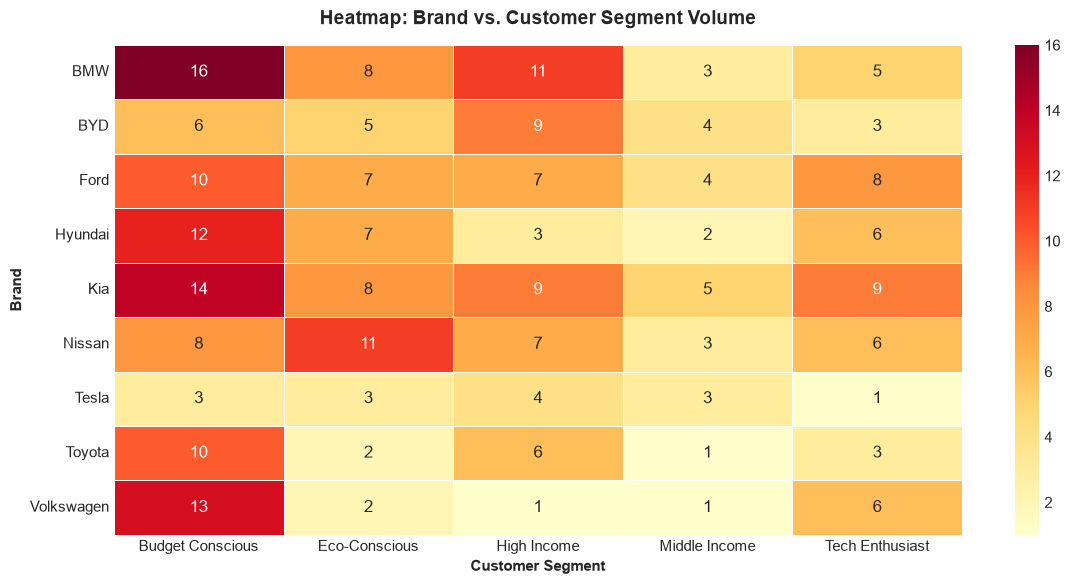

In [30]:
# Plot 2: Heatmap for Brand vs Customer Segment
plt.figure(figsize = (12, 6))
sns.heatmap(brand_segment_ct, annot=True, fmt='d', cmap='YlOrRd', cbar=True, linewidth=0.5)
plt.title('Heatmap: Brand vs. Customer Segment Volume', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Customer Segment', fontsize=11, fontweight='bold')
plt.ylabel('Brand', fontsize=11, fontweight='bold')
plt.tight_layout()
print("Heatmap: Brand vs. Customer Segment Volume generated successfully:")
plt.show()

In [31]:
# Top Model per Customer Segment
model_segment_top = car.groupby(['Customer_Segment', 'Brand', 'Model']).size().reset_index(name='Count') 
model_segemnt_top = model_segment_top.sort_values(['Customer_Segment', 'Count'], ascending=[True,False])

print("\nTop 3 Models per Customer Segment:")
for seg in car['Customer_Segment'].unique():
    print(f"\n--- Segment: {seg} ---")
    sub = model_segment_top[model_segment_top['Customer_Segment'] == seg].head(3)
    print(sub[['Brand', 'Model', 'Count']].to_string(index=False))


Top 3 Models per Customer Segment:

--- Segment: Budget Conscious ---
Brand      Model  Count
  BMW Corolla EV      1
  BMW Elantra EV      1
  BMW     Han EV      4

--- Segment: Tech Enthusiast ---
Brand      Model  Count
  BMW Corolla EV      1
  BMW     Han EV      2
  BMW     Rio EV      1

--- Segment: Eco-Conscious ---
Brand      Model  Count
  BMW      Ariya      1
  BMW Elantra EV      1
  BMW     Han EV      1

--- Segment: High Income ---
Brand      Model  Count
  BMW     Atto 3      1
  BMW Elantra EV      1
  BMW       ID.3      2

--- Segment: Middle Income ---
Brand      Model  Count
  BMW Corolla EV      1
  BMW       ID.4      1
  BMW         i4      1


In [32]:
# Model Breakdown by Customer Segment across brands
top_models_segment = car.groupby(['Customer_Segment', 'Brand', 'Model']).size().reset_index(name='Listings').sort_values(['Customer_Segment', 'Listings'], ascending=[True, False])

# Sumary of top brand-model per segment
summary_list = []
for seg in car['Customer_Segment'].unique():
    sub = top_models_segment[top_models_segment['Customer_Segment'] == seg].head(3)
    models_str = ", ".join([f"{r['Brand']} {r['Model']} ({r['Listings']})" for _, r in sub.iterrows()])
    summary_list.append({'Customer Segment': seg, 'Total Listings': len(car[car['Customer_Segment'] == seg]), 'Top Models': models_str})

seg_car = pd.DataFrame(summary_list)
print(seg_car.to_string(index=False))

Customer Segment  Total Listings                                                Top Models
Budget Conscious              92 BMW Han EV (4), Hyundai Rio EV (4), Nissan Corolla EV (4)
 Tech Enthusiast              47        Volkswagen ID.4 (4), BMW Han EV (2), Ford Leaf (2)
   Eco-Conscious              53           Kia Rio EV (3), BMW ID.5 (2), BMW Tucson EV (2)
     High Income              57          BMW ID.3 (2), BMW Model 3 (2), BMW Tucson EV (2)
   Middle Income              26              BMW Corolla EV (1), BMW ID.4 (1), BMW i4 (1)


**Key Analytical Findings**

* **Dominant Buyer Demographic:** Budget Conscious buyers constitute the largest segment overall ($N=92$, $33.5\%$), commanding over $\mathbf{50\%}$ of all Volkswagen and Toyota listings.

* **Premium & High-Income Concentration:** BMW holds the highest individual volume within the High Income segment ($N=11$), followed closely by BYD ($N=9$) and Kia ($N=9$).

* **Tech Enthusiast Focus:** Volkswagen ID.4 leads the Tech Enthusiast segment ($N=4$), while Ford and Kia also capture high proportions of tech-focused listings.

* **Eco-Conscious Preferences:** Nissan achieves its largest single share in the Eco-Conscious category ($N=11$), led by models like the Nissan Ariya and Nissan Leaf.

## 7. Fast Charging Option by Car Brand

In [33]:
# Load Dataset
car = pd.read_csv(r"C:\Users\MCHARO\Downloads\test (1).csv")

# Cross tabulation of Brand vs Fast Charging
brand_fc = pd.crosstab(car['Brand'], car['Fast_Charging_Option'], margins = True)
brand_fc_pct = pd.crosstab(car['Brand'], car['Fast_Charging_Option'], normalize = 'index') * 100

# Cross tabulation of Vehicle Type vs Fast Charging
type_fc = pd.crosstab(car['Vehicle_Type'], car['Fast_Charging_Option'], margins = True)
type_fc_pct = pd.crosstab(car['Vehicle_Type'], car['Fast_Charging_Option'], normalize = 'index') * 100

# Top Models with Fast Charging
top_models_fc = car[car['Fast_Charging_Option'] == 'Yes'].groupby(['Brand', 'Model', 'Vehicle_Type']).size().reset_index(name='Fast_Charge_Count').sort_values('Fast_Charge_Count', ascending=False)

print("Brand vs Fast Charging: \n", brand_fc)
print("\nBrand vs Fast Charging (%): \n", brand_fc_pct)
print("\nVehicle Type vs Fast Charging: \n", type_fc)
print("\nVehicle Type vs Fast Charing (%): \n", type_fc_pct)
print("\nTop 10 Fast-Charging Vehicles: \n", top_models_fc.head(10))

Brand vs Fast Charging: 
 Fast_Charging_Option  No  Yes  All
Brand                             
BMW                   17   26   43
BYD                   10   17   27
Ford                  10   26   36
Hyundai               11   19   30
Kia                   11   34   45
Nissan                 9   26   35
Tesla                  5    9   14
Toyota                 6   16   22
Volkswagen            12   11   23
All                   91  184  275

Brand vs Fast Charging (%): 
 Fast_Charging_Option         No        Yes
Brand                                     
BMW                   39.534884  60.465116
BYD                   37.037037  62.962963
Ford                  27.777778  72.222222
Hyundai               36.666667  63.333333
Kia                   24.444444  75.555556
Nissan                25.714286  74.285714
Tesla                 35.714286  64.285714
Toyota                27.272727  72.727273
Volkswagen            52.173913  47.826087

Vehicle Type vs Fast Charging: 
 Fast_Charging_Op

Fast Charging Avalilability by Vehicle Type generated successfully:


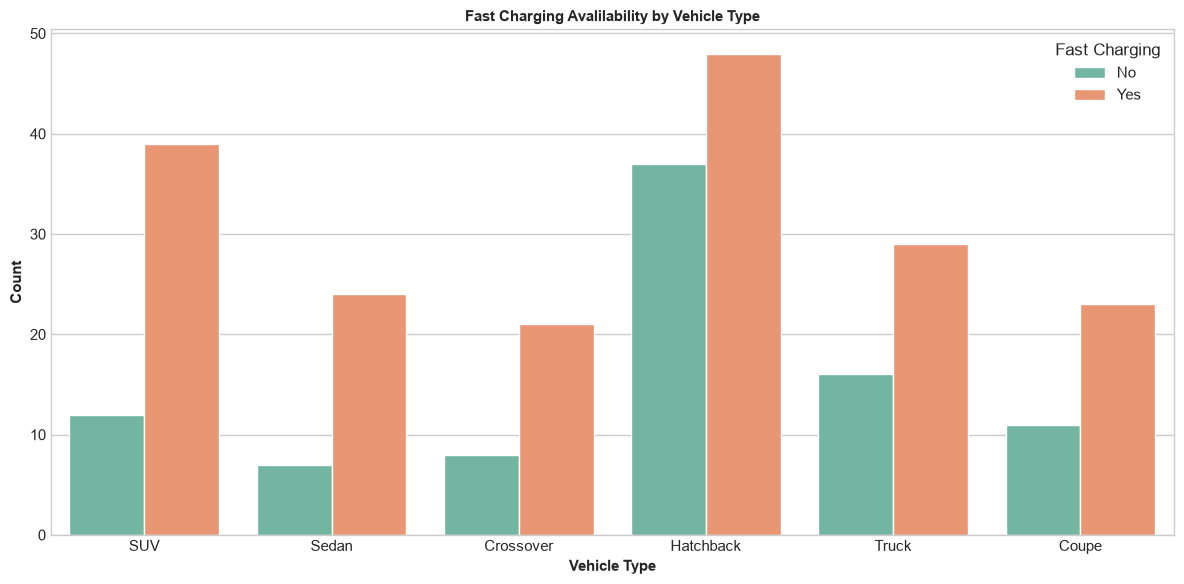

In [34]:
# Plot 1: Fast Charging Distribution by Vehicle Type
plt.figure(figsize=(12, 6))
sns.countplot(data=car, x='Vehicle_Type', hue='Fast_Charging_Option', palette='Set2')
plt.title('Fast Charging Avalilability by Vehicle Type', fontsize = 11, fontweight = 'bold')
plt.xlabel('Vehicle Type', fontsize=11, fontweight='bold')
plt.ylabel('Count', fontsize=11, fontweight='bold')
plt.legend(title='Fast Charging', loc='upper right')
plt.tight_layout()
print('Fast Charging Avalilability by Vehicle Type generated successfully:')
plt.show()

Fast Charging Availability by Car Brand generated successfully:


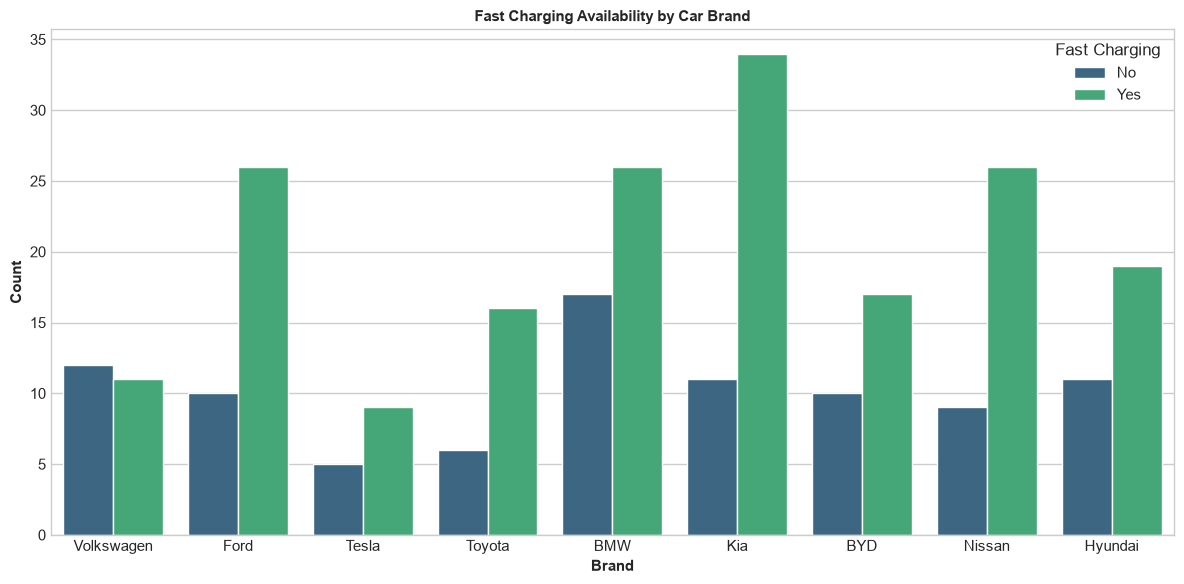

In [35]:
# Plot 2: Fast Charging Distribution by Brand
plt.figure(figsize=(12, 6))
sns.countplot(data=car, x='Brand', hue='Fast_Charging_Option', palette='viridis')
plt.title('Fast Charging Availability by Car Brand', fontsize=11, fontweight='bold')
plt.xlabel('Brand', fontsize=11, fontweight='bold')
plt.ylabel('Count', fontsize=11, fontweight='bold')
plt.legend(title='Fast Charging', loc='upper right')
plt.tight_layout()
print('Fast Charging Availability by Car Brand generated successfully:')
plt.show()

In [36]:
# Code block to demonstrate analysis and visualization generation

# Load Dataset
car = pd.read_csv(r"C:\Users\MCHARO\Downloads\test (1).csv")

# Aggregating Fast Charging statistics across Vehicle Types and Brands
type_summary = car.groupby('Vehicle_Type')['Fast_Charging_Option'].value_counts(normalize = True).unstack() * 100
brand_summary = car.groupby('Brand')['Fast_Charging_Option'].value_counts(normalize = True).unstack() * 100

print("Vehicle Type Fast Charging Share:\n", type_summary)
print("\nBrand Fast Charging Share:\n", brand_summary)

Vehicle Type Fast Charging Share:
 Fast_Charging_Option         No        Yes
Vehicle_Type                              
Coupe                 32.352941  67.647059
Crossover             27.586207  72.413793
Hatchback             43.529412  56.470588
SUV                   23.529412  76.470588
Sedan                 22.580645  77.419355
Truck                 35.555556  64.444444

Brand Fast Charging Share:
 Fast_Charging_Option         No        Yes
Brand                                     
BMW                   39.534884  60.465116
BYD                   37.037037  62.962963
Ford                  27.777778  72.222222
Hyundai               36.666667  63.333333
Kia                   24.444444  75.555556
Nissan                25.714286  74.285714
Tesla                 35.714286  64.285714
Toyota                27.272727  72.727273
Volkswagen            52.173913  47.826087


**Key Insights**

* **Highest Adoption by Body Style:** Sedans ($77.4\%$) and SUVs ($76.5\%$) show the highest concentration of fast-charging capabilities.

* **Hatchback Lag:** Hatchbacks have the lowest fast-charging adoption rate ($56.5\%$), reflecting entry-level positioning in urban commuter segments.

* **Top OEM Performers:** Kia ($75.6\%$), Nissan ($74.3\%$), and Toyota ($72.7\%$) lead in standardizing fast charging across their offered models.

* **Lowest Brand Share:** Volkswagen is the only brand where fewer than half ($47.8\%$) of available listings feature fast charging.

## 8. Car brand and model vs discount percentage

In [37]:
# Load Dataset
car = pd.read_csv(r"C:\Users\MCHARO\Downloads\test (1).csv")

# Check Column Names
print("Columns:", car.columns.to_list())

# Discount Percentage stats by Brand
brand_discount = (
    car.groupby("Brand")["Discount_Percentage"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .reset_index()
    .sort_values(by="mean", ascending=False)
)

print("\nDiscount Percentage Summary Stats by Brand:\n", brand_discount)

# Discount Percentage Stats by Brand & Model
model_discount = car.groupby(['Brand', 'Model'])['Discount_Percentage'].agg(['count', 'mean', 'min', 'max']).reset_index()
model_discount = model_discount.sort_values(by='mean', ascending=False)
print("\nTop 10 Highest Discount Models:\n", model_discount.head(10))

Columns: ['Date', 'Region', 'Brand', 'Model', 'Vehicle_Type', 'Battery_Capacity_kWh', 'Discount_Percentage', 'Customer_Segment', 'Fast_Charging_Option']

Discount Percentage Summary Stats by Brand:
         Brand  count       mean  median       std  min  max
5      Nissan     35  11.542857    13.0  6.288846    0   20
8  Volkswagen     23   9.695652     8.0  5.513906    2   19
2        Ford     36   8.722222     8.5  6.231767    0   19
1         BYD     27   8.296296     9.0  4.850177    0   17
3     Hyundai     30   8.266667     7.0  5.400724    1   19
7      Toyota     22   8.136364     8.0  5.285159    0   17
4         Kia     45   7.911111     6.0  5.869111    0   19
0         BMW     43   7.232558     6.0  5.348953    0   18
6       Tesla     14   6.428571     6.0  4.925823    1   16

Top 10 Highest Discount Models:
           Brand    Model  count  mean  min  max
40         Ford       iX      1  19.0   19   19
75       Nissan     ID.4      1  19.0   19   19
76       Nissan     ID.

Discount Percentage Distribution by Car Brand generated successfully:


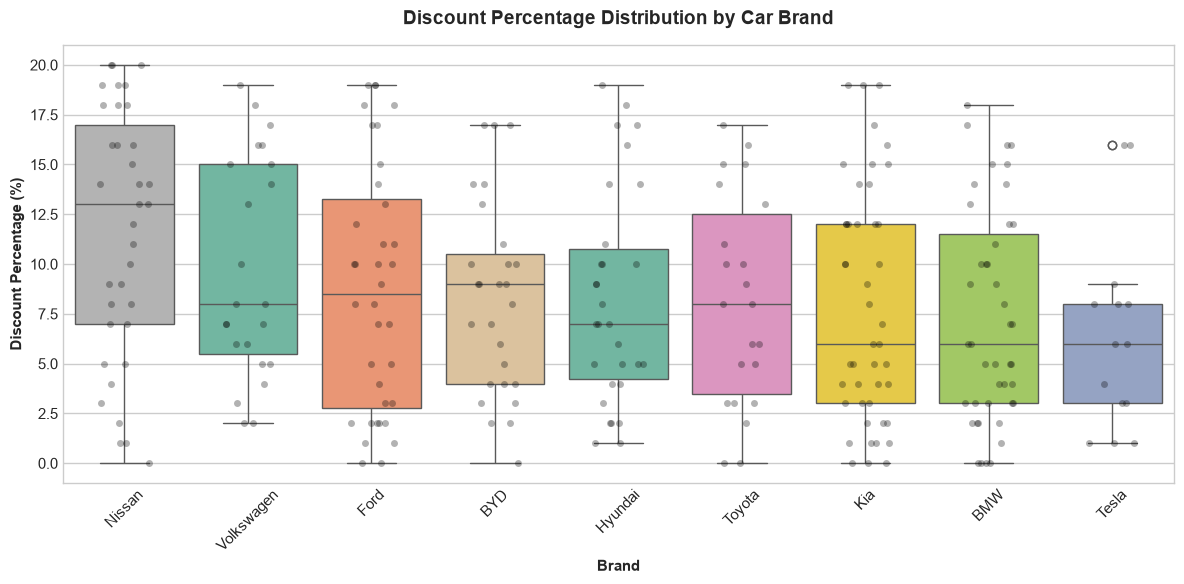

In [38]:
# Plot 1: Boxplot of Discount Percentage by Brand
plt.figure(figsize=(12, 6))
sns.boxplot(data=car, x='Brand', y='Discount_Percentage', hue='Brand', palette='Set2', order=brand_discount['Brand'], legend=False)
sns.stripplot(data=car, x='Brand', y='Discount_Percentage', color='black', alpha=0.3, jitter=0.2, order=brand_discount['Brand'])
plt.title('Discount Percentage Distribution by Car Brand', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Brand', fontsize=11, fontweight='bold')
plt.ylabel('Discount Percentage (%)', fontsize=11, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
print("Discount Percentage Distribution by Car Brand generated successfully:")
plt.show()

Top 15 Car Models by Average Discount Percentage (%) generated successfully:


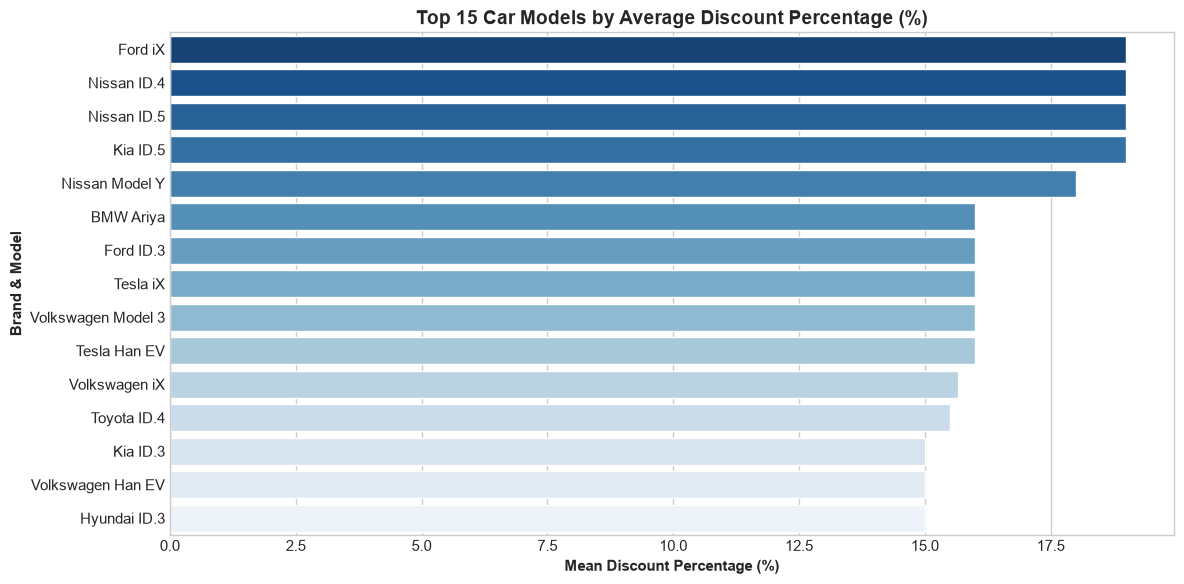

In [39]:
# Plot 2: Average Discount Percentage by Model (Top 15 Models)
plt.figure(figsize=(12, 6))
top_15_models = model_discount.head(15).copy()
top_15_models['Brand_Model'] = top_15_models['Brand'] + ' ' + top_15_models['Model']
sns.barplot(data=top_15_models, x='mean', hue = 'Brand_Model',y='Brand_Model', palette='Blues_r')
plt.title('Top 15 Car Models by Average Discount Percentage (%)', fontsize=14, fontweight='bold')
plt.xlabel('Mean Discount Percentage (%)', fontsize=11, fontweight='bold')
plt.ylabel('Brand & Model', fontsize=11, fontweight='bold')
plt.tight_layout()
print("Top 15 Car Models by Average Discount Percentage (%) generated successfully:")
plt.show()

In [40]:
# Structured Table for Output
brand_table = brand_discount[['Brand', 'count','mean', 'median', 'std', 'min', 'max']].copy()
brand_table.columns = ['Brand', 'Listings (N)', 'Mean (%)', 'Median (%)', 'Std Dev', 'Min (%)', 'Max (%)']
print("Brand Discount Table:\n", brand_table.to_string(index=False))
print("\nTop 10 Discount Models:\n", model_discount.head(10).to_string(index=False))

Brand Discount Table:
      Brand  Listings (N)  Mean (%)  Median (%)  Std Dev  Min (%)  Max (%)
    Nissan            35 11.542857        13.0 6.288846        0       20
Volkswagen            23  9.695652         8.0 5.513906        2       19
      Ford            36  8.722222         8.5 6.231767        0       19
       BYD            27  8.296296         9.0 4.850177        0       17
   Hyundai            30  8.266667         7.0 5.400724        1       19
    Toyota            22  8.136364         8.0 5.285159        0       17
       Kia            45  7.911111         6.0 5.869111        0       19
       BMW            43  7.232558         6.0 5.348953        0       18
     Tesla            14  6.428571         6.0 4.925823        1       16

Top 10 Discount Models:
      Brand   Model  count  mean  min  max
      Ford      iX      1  19.0   19   19
    Nissan    ID.4      1  19.0   19   19
    Nissan    ID.5      1  19.0   19   19
       Kia    ID.5      1  19.0   19   19
 

Heatmap to show Car Brand & Model vs Discount Percentage

Heatmap: Average Discount Percentage (%) by Car Brand and Model generated successfully:


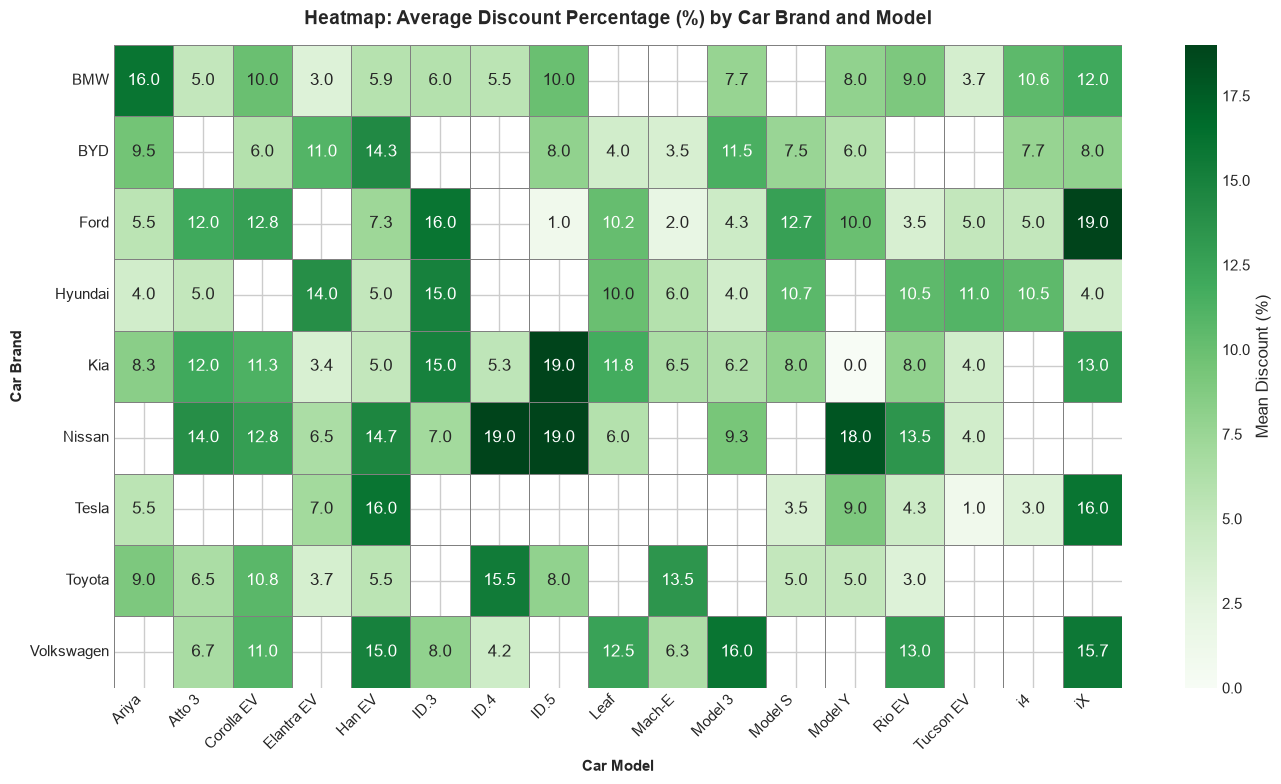

In [41]:
# Load Dataset
car = pd.read_csv(r"C:\Users\MCHARO\Downloads\test (1).csv")

# Pivot Table: Brands (index) vs Models (Columns) aggragated by mean Discount_Percentage
pivot_discount = car.pivot_table(index='Brand', columns='Model', values='Discount_Percentage', aggfunc='mean')

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_discount, annot=True, fmt=".1f", cmap='Greens', cbar_kws={'label': 'Mean Discount (%)'}, linewidths=0.5, linecolor='gray')
plt.title('Heatmap: Average Discount Percentage (%) by Car Brand and Model', fontsize = 14, fontweight='bold', pad=15)
plt.xlabel('Car Model', fontsize=11, fontweight='bold')
plt.ylabel('Car Brand', fontsize=11, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
print("Heatmap: Average Discount Percentage (%) by Car Brand and Model generated successfully:")
plt.show()

Hierarchical Treemap to show Car Brand & Model vs Discount Percentage

In [42]:
import plotly.express as px

fig = px.treemap(
    car,
    path=["Brand", "Model"],
    values="Discount_Percentage",
    color="Discount_Percentage",
    color_continuous_scale="Greens",
)
print("Hierarchical Treemap to show Car Brand & Model vs Discount Percentage generated successfully:")
fig.show()

Hierarchical Treemap to show Car Brand & Model vs Discount Percentage generated successfully:


Boxplot to show Car Brand & Model vs Discount Percentage

Boxplot to show Car Brand & Model vs Discount Percentage generated successfully:


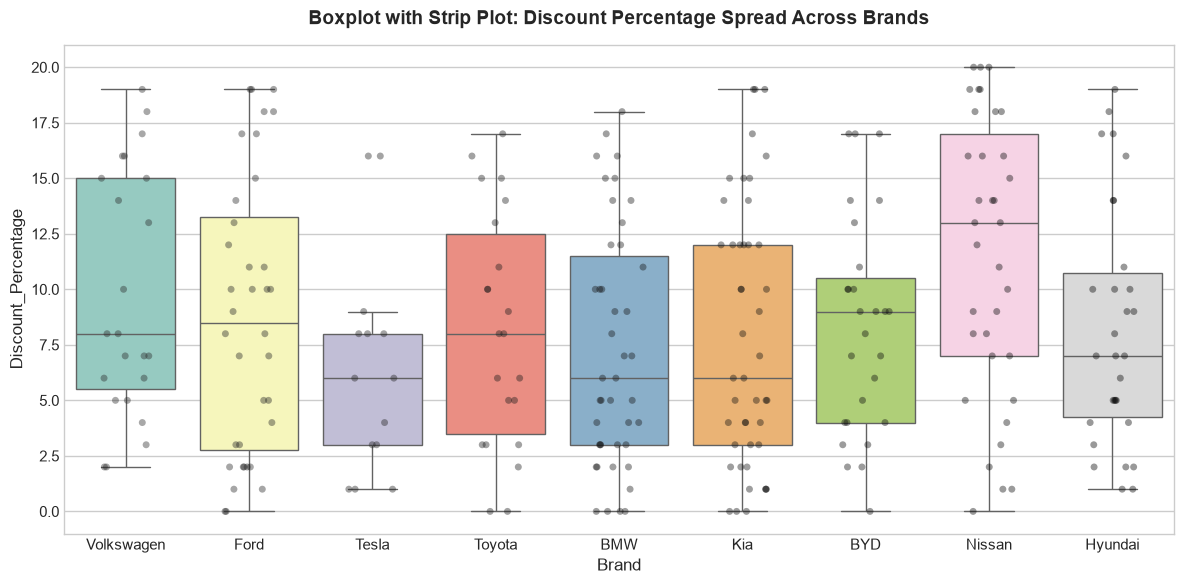

In [43]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=car, x="Brand",hue="Brand", y="Discount_Percentage", palette="Set3", showfliers=False
)
sns.stripplot(
    data=car,
    x="Brand",
    hue="Brand",
    y="Discount_Percentage",
    palette='dark:black',
    alpha=0.4,
    jitter=0.2,
)
plt.title('Boxplot with Strip Plot: Discount Percentage Spread Across Brands', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
print("Boxplot to show Car Brand & Model vs Discount Percentage generated successfully:")
plt.show()

Bubble Chart to show Car Brand & Model vs Discount Percentage

Bubble Chart to show Car Brand & Model vs Discount Percentage generated successfully:


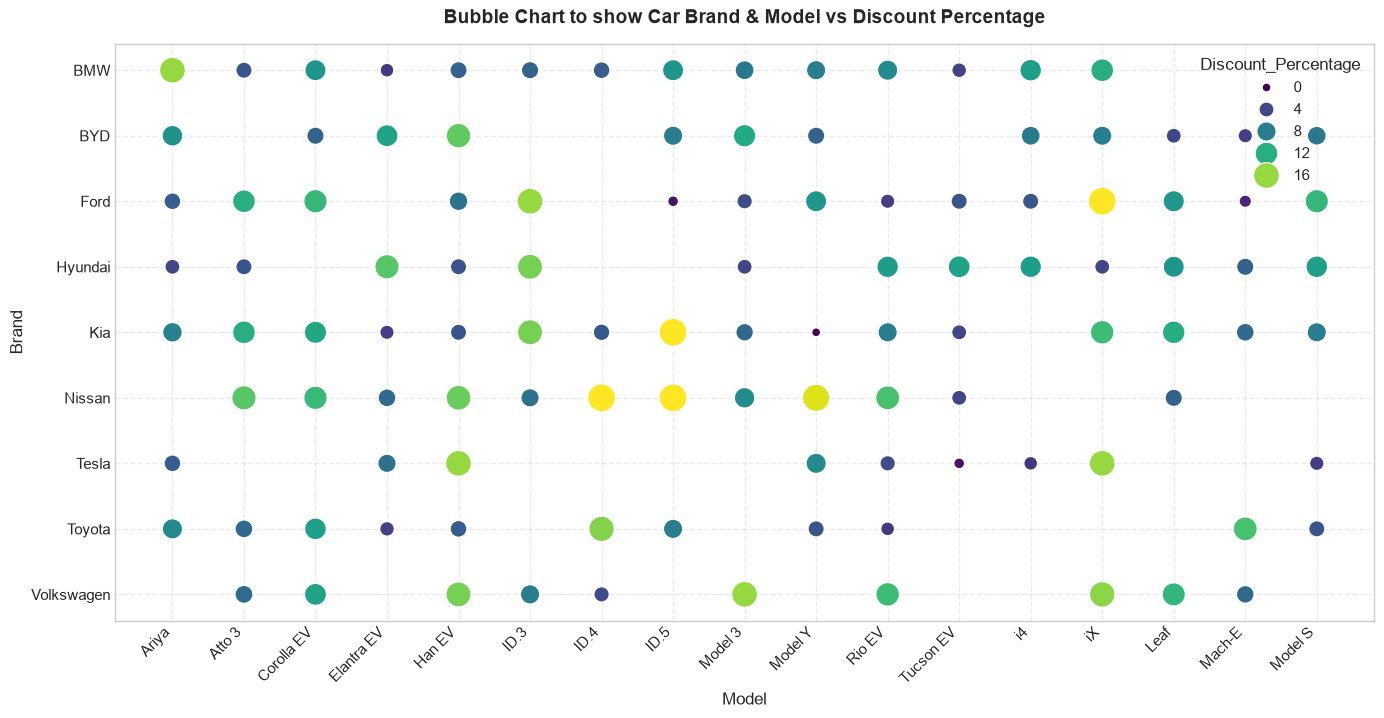

In [44]:
plt.figure(figsize=(14, 7))
model_agg = (
    car.groupby(["Brand", "Model"])["Discount_Percentage"].mean().reset_index()
)

sns.scatterplot(
    data=model_agg,
    x="Model",
    y="Brand",
    size="Discount_Percentage",
    hue="Discount_Percentage",
    sizes=(40, 400),
    palette="viridis",
)
plt.xticks(rotation=45, ha="right")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.title('Bubble Chart to show Car Brand & Model vs Discount Percentage', fontsize = 14, fontweight='bold', pad=15)
print("Bubble Chart to show Car Brand & Model vs Discount Percentage generated successfully:")
plt.show()

Faceted Bar Chart: Average Discount Percentage by Brand & Model

Faceted Bar Chart: Average Discount Percentage by Brand & Model generated successfully:


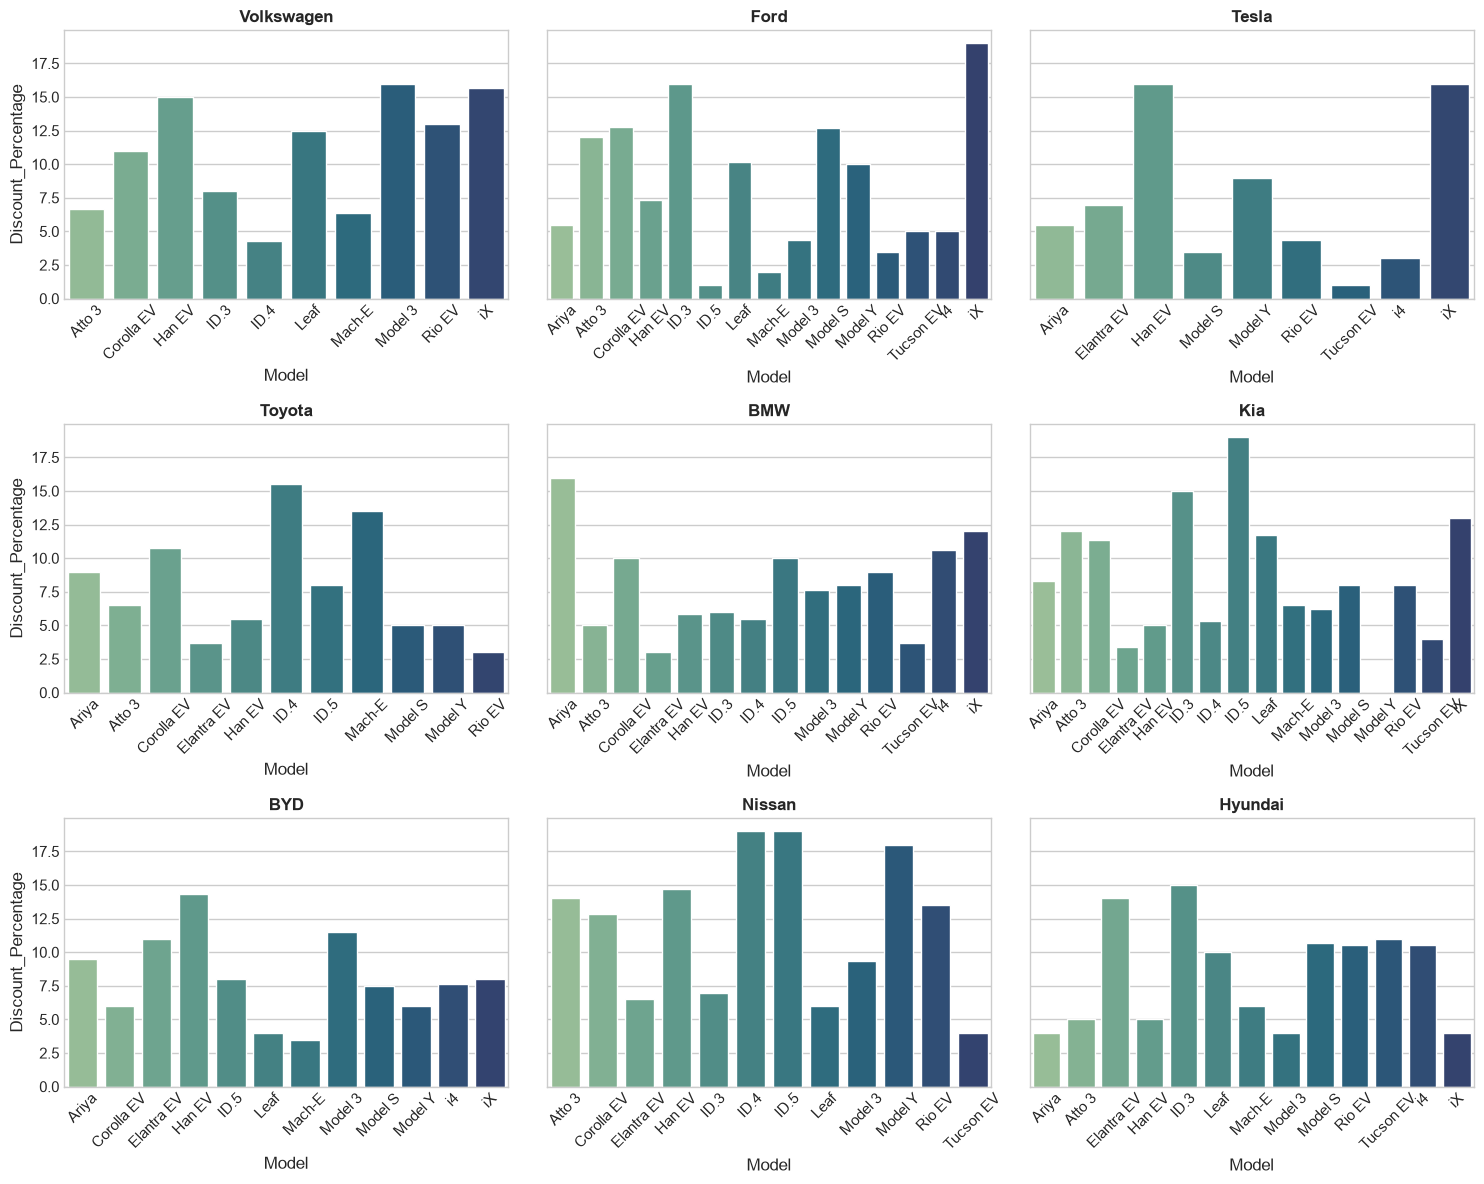

In [48]:
# Load Dataset
car = pd.read_csv(r"C:\Users\MCHARO\Downloads\test (1).csv")
top_brands = car["Brand"].unique()

fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharey=True)
axes = axes.flatten()
plt.title('Faceted Bar Chart: Average Discount Percentage by Brand & Model', fontsize = 14, fontweight='bold', pad=15)
for i, brand in enumerate(top_brands):
    brand_car = (
        car[car["Brand"] == brand]
        .groupby("Model")["Discount_Percentage"]
        .mean()
        .reset_index()
    )
    sns.barplot(
        data=brand_car,
        x="Model",
        hue="Model",
        y="Discount_Percentage",
        ax=axes[i],
        palette="crest",
    )
    axes[i].set_title(brand, fontweight="bold")
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
print("Faceted Bar Chart: Average Discount Percentage by Brand & Model generated successfully:")
plt.show()

Across the dataset ($N = 275$), average discount percentages vary significantly by car brand and model, ranging from 0.0% to 20.0%, with an overall brand-level average around 6.4% to 11.5%. Nissan offers the highest mean discounts (11.54% overall, peaking at 19.0% on models like the ID.4 and ID.5), followed closely by Volkswagen (9.70%) and Ford (8.72%). Conversely, Tesla maintains the most rigid pricing structure with the lowest average discount rate (6.43%), closely followed by BMW (7.23%) and Kia (7.91%). Individual model discounts peak at 19.0%–20.0% across select premium listings (such as the Ford iX, Kia ID.5, and Nissan ID series), while models like the Kia Model Y record no discount (0.0%), demonstrating that manufacturers apply heavy, selective discounting to specific models while keeping core high-demand lines near MSRP.